Nuclear Gamma Radiative Transition Rates

Jaideep Taggart Singh

2025-11-11

PHYSICAL REVIEW C 92, 054324 (2015)

https://doi.org/10.1103/PhysRevC.92.054324

using un-numbered equations in the Appendix A

In [1]:
import numpy as np
import random
import statistics
import scipy.special
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

plt.style.use('ggplot')

https://en.wikipedia.org/wiki/Half-life

$t_{1/2} = \tau \log(2)$

https://en.wikipedia.org/wiki/Planck_constant

https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.factorial2.html#scipy.special.factorial2

https://en.wikipedia.org/wiki/Fine-structure_constant

https://en.wikipedia.org/wiki/Planck_constant

https://en.wikipedia.org/wiki/Proton

In [2]:
alpha = 1.0/137.035999177        # unitless
hbarc = 197.3269804E6            # eV*fm
hbar = 4.135667696E-15/2.0/np.pi # eV*sec

In [3]:
# Bwu for EL transitions
# output units = fm^(2L)
def BwuE(A,L):
    e2 = alpha
    R0 = 1.2*A**(1.0/3.0) # fm
    return (e2/4.0/np.pi)*((3/(3+L))**2)*(R0**(2*L))

In [4]:
print("W.u. scale for B(A=232,E1): PRC 2015 convention = ",BwuE(232,1)," fm^2")
print("W.u. scale for B(A=232,E1): NPA 1993 convention = ",BwuE(232,1)/alpha," e^2fm^2")

W.u. scale for B(A=232,E1): PRC 2015 convention =  0.01775957113464947  fm^2
W.u. scale for B(A=232,E1): NPA 1993 convention =  2.433700575391698  e^2fm^2


In [5]:
# Bwu for ML transitions
# output units = fm^(2L)/(eV*fm)^2
def BwuM(A,L):
    Mp = 938.27208943*1.0E6     # eV
    R0 = 1.2*A**(1.0/3.0)  # fm
    return (10.0*BwuE(A,L))/(Mp*R0)**2

In [6]:
#Gamma rad width in eV fo ML transitions
# output units = eV
def gammaradM(A, L, omega, B):
    numer = 8.0*np.pi*(L+1.0)/L*(omega**(2*L+1))*B*BwuM(A,L)
    denom = (scipy.special.factorial2(2*L+1))**2
    output = numer/denom # eV^(2L+1)*fm^(2L)/(eV*fm)^2 = eV*(eV*fm)^(2L-2)
    return output/(hbarc**(2*L-2)) # eV - had to include enough factors of hbarc to make this work

In [7]:
#Gamma rad width in eV fo EL transitions
# output units = eV
def gammaradE(A, L, omega, B):
    numer = 8.0*np.pi*(L+1.0)/L*(omega**(2*L+1))*B*BwuE(A,L)
    denom = (scipy.special.factorial2(2*L+1))**2
    output = numer/denom # eV^(2L+1)*fm^(2L) = eV*(eV*fm)^(2L)
    return output/(hbarc**(2*L)) # eV - had to include enough factors of hbarc to make this work

In [8]:
hbar/gammaradE(229, 1, 60, 3E-4)

4.022279233008074

PHYSICAL REVIEW C 92, 054324 (2015)

https://doi.org/10.1103/PhysRevC.92.054324

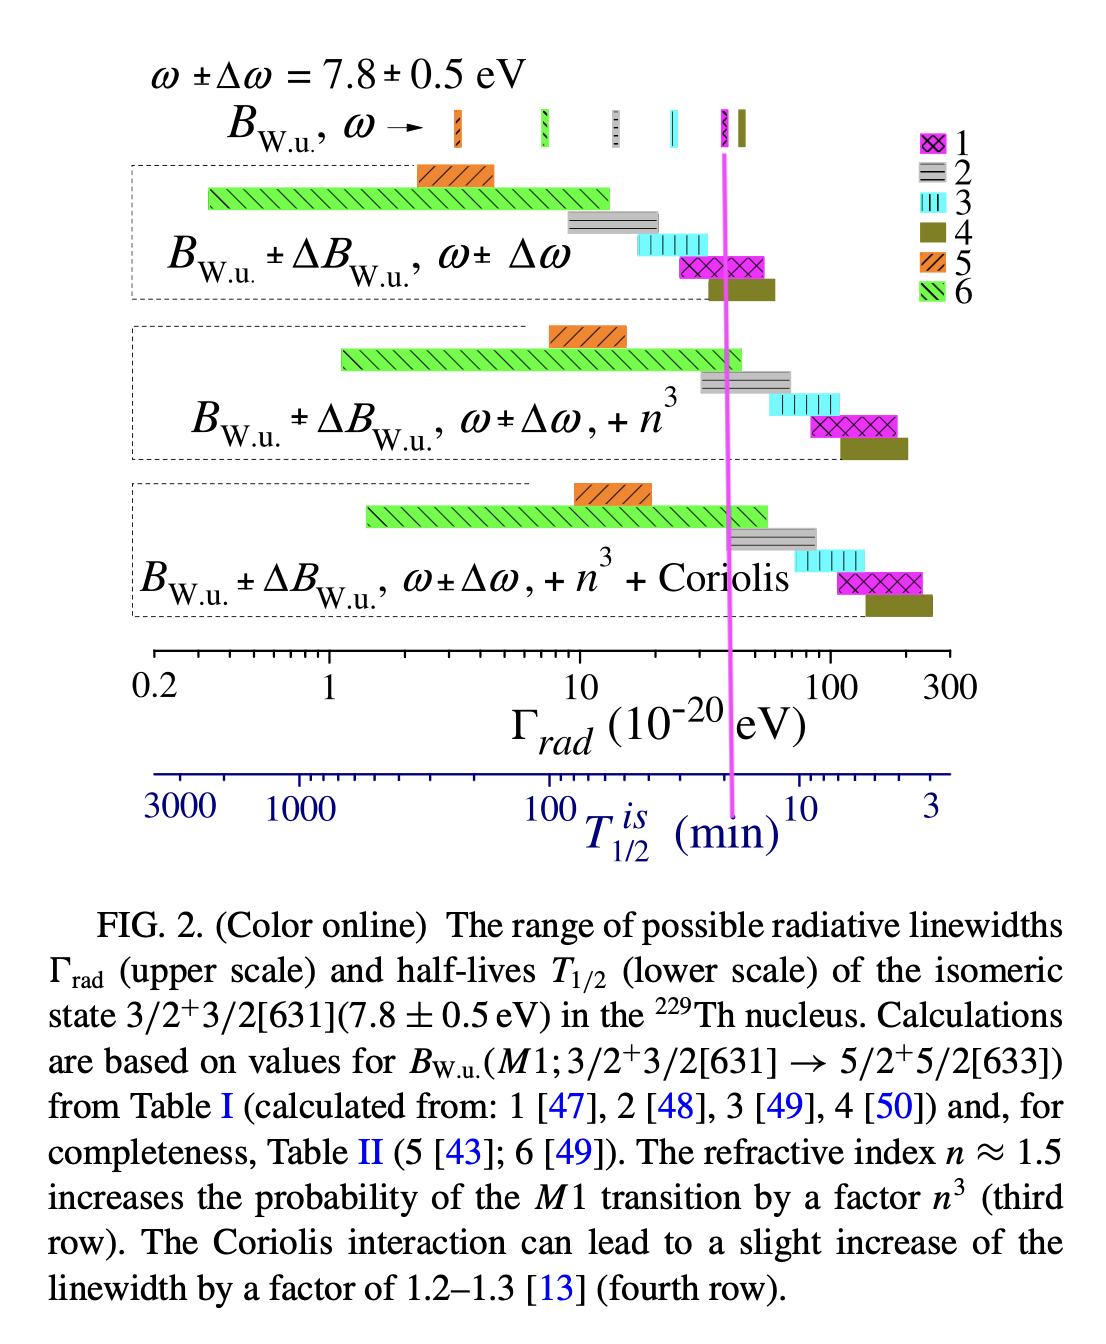

In [9]:
A = 229
L = 1
omega = 7.8
Bmodel1 = 3.83E-2
grM1 = gammaradM(A, L, omega, Bmodel1)
# if L = 1, 
# then output units = eV^(2+1)*fm^(2)/(eV*fm)^2 
#                   = eV^3*fm^2/(eV*fm)^2 = eV
print(grM1, "eV for model 1 (pink)")
print("4E-19 eV for model 1 (pink) by eye for Th-229")

3.766433679636591e-19 eV for model 1 (pink)
4E-19 eV for model 1 (pink) by eye for Th-229


In [10]:
tau = hbar/grM1
thalf = tau*np.log(2.0)
print(np.round(thalf/60.0,1),"mins for model 1 (pink)")
print("20 mins for model 1 (pink) by eye for Th-229")

20.2 mins for model 1 (pink)
20 mins for model 1 (pink) by eye for Th-229


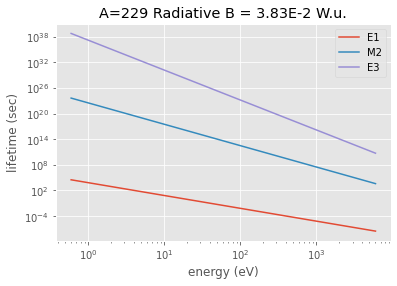

In [11]:
npts = 100
mid = np.log10(60.0)
ran = 2
omegas = np.logspace(mid-ran,mid+ran,npts)
A = 229
Bmodel1 = 3.83E-2
E1gammarads = gammaradE(A, 1, omegas, Bmodel1)
E1taus = hbar/E1gammarads
M2gammarads = gammaradM(A, 2, omegas, Bmodel1)
M2taus = hbar/M2gammarads
E3gammarads = gammaradE(A, 3, omegas, Bmodel1)
E3taus = hbar/E3gammarads
plt.plot(omegas,E1taus,label="E1")
plt.plot(omegas,M2taus,label="M2")
plt.plot(omegas,E3taus,label="E3")
plt.xscale("log")
plt.yscale("log")
plt.title("A=229 Radiative B = 3.83E-2 W.u.")
plt.xlabel('energy (eV)')
plt.ylabel('lifetime (sec)')
plt.legend()

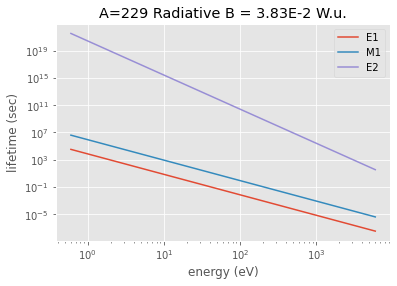

In [12]:
M1gammarads = gammaradM(A, 1, omegas, Bmodel1)
M1taus = hbar/M1gammarads
E2gammarads = gammaradE(A, 2, omegas, Bmodel1)
E2taus = hbar/E2gammarads
plt.plot(omegas,E1taus,label="E1")
plt.plot(omegas,M1taus,label="M1")
plt.plot(omegas,E2taus,label="E2")
plt.xscale("log")
plt.yscale("log")
plt.title("A=229 Radiative B = 3.83E-2 W.u.")
plt.xlabel('energy (eV)')
plt.ylabel('lifetime (sec)')
plt.legend()
plt.savefig("A229-E1-M1-E2.jpg")

PHYSICAL REVIEW LETTERS 132, 182501 (2024)

https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.132.182501

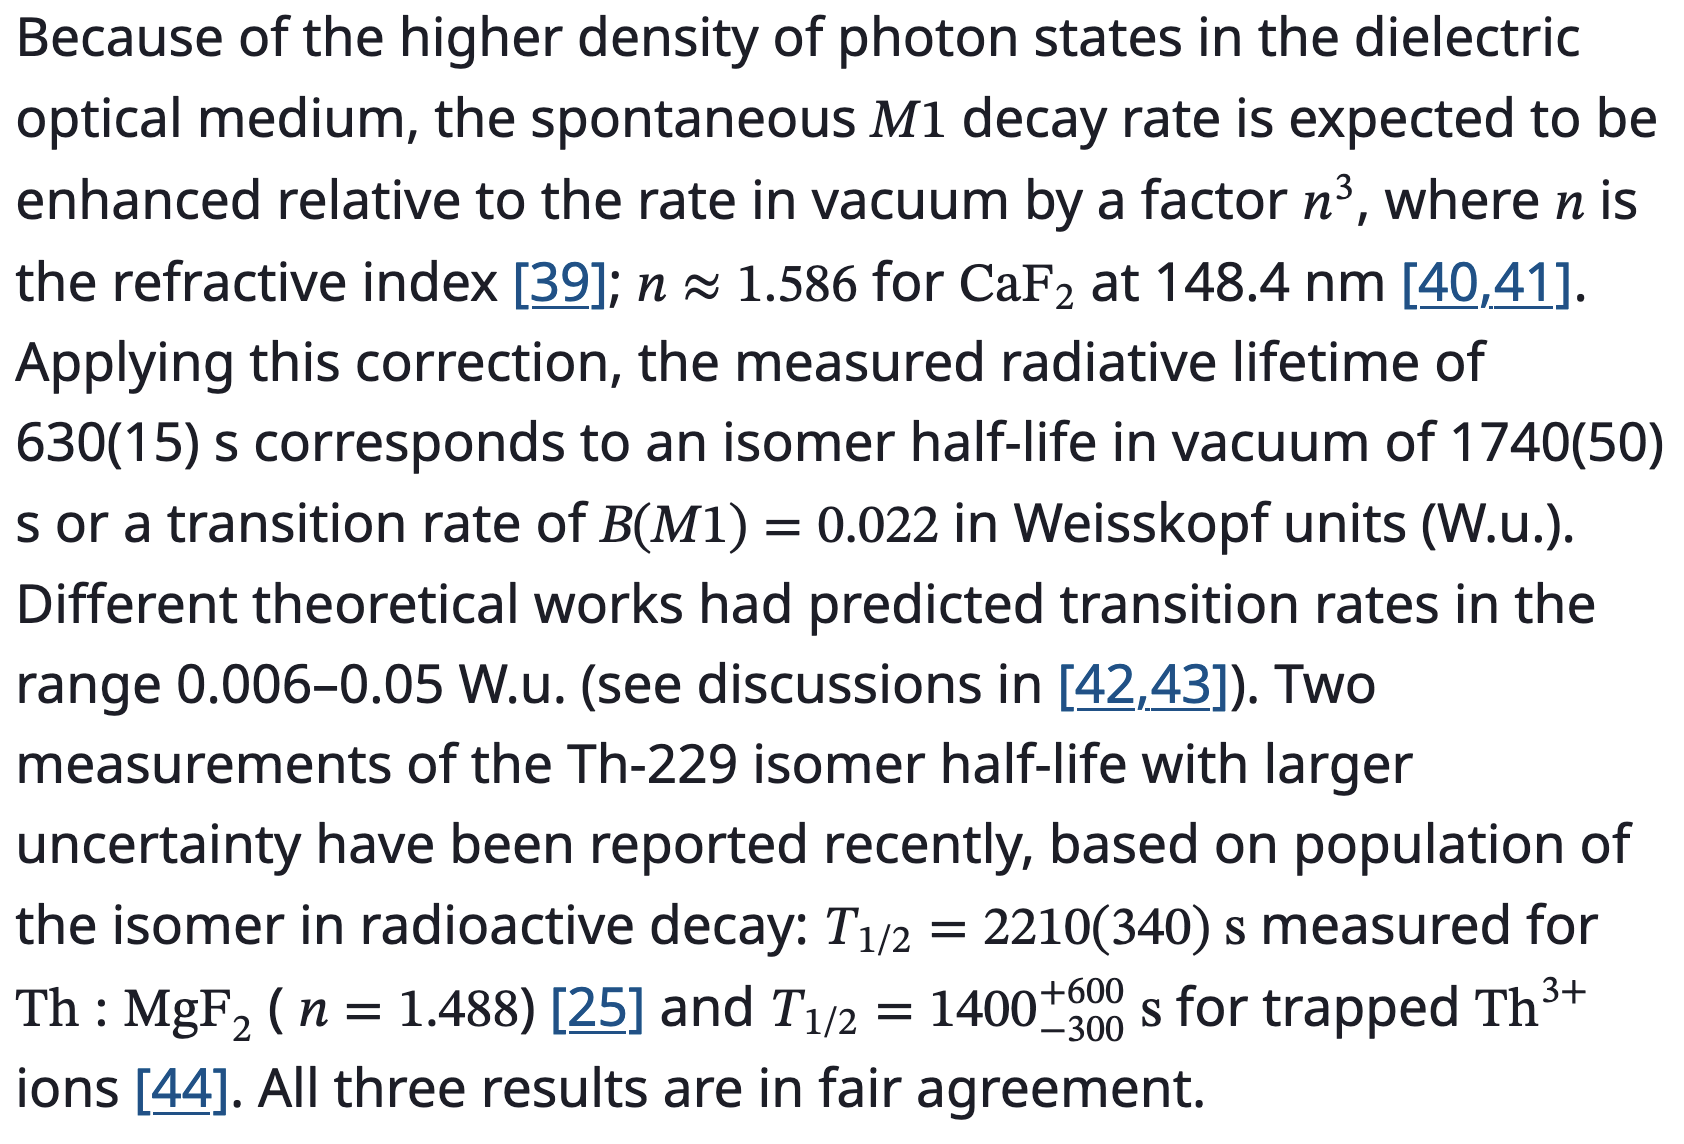

In [13]:
BM1Th229 = 0.022
print("M1 radiative half-life for Th-229 according to formula in sec =",np.round(np.log(2)*hbar/gammaradM(229, 1, 8.36, BM1Th229)))
print("M1 radiative half-life for Th-229 according to measurement  = (1740+/-50) sec")

M1 radiative half-life for Th-229 according to formula in sec = 1713.0
M1 radiative half-life for Th-229 according to measurement  = (1740+/-50) sec


54.84926226829192  msec for Pa-229 E1 @ 60 eV B = 0.022 Wu


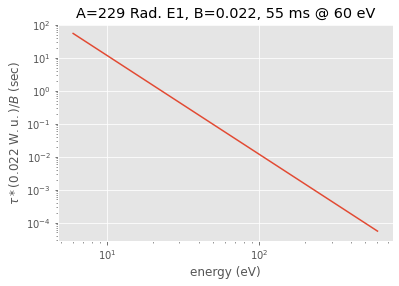

In [14]:
npts = 100
mid = np.log10(60.0)
ran = 1
omegas = np.logspace(mid-ran,mid+ran,npts)
A = 229
E1gammarads = gammaradE(A, 1, omegas, BM1Th229)
E1taus = hbar/E1gammarads

plt.plot(omegas,E1taus)
plt.xscale("log")
plt.yscale("log")
plt.title("A=229 Rad. E1, B=0.022, 55 ms @ 60 eV")
plt.xlabel('energy (eV)')
plt.ylabel('$\\tau*(0.022\ \mathrm{W.u.})/B$ (sec)')

print(1000*hbar*(0.022/0.022)/gammaradE(A, 1, 60.0, BM1Th229), " msec for Pa-229 E1 @ 60 eV B = 0.022 Wu")

In [15]:
A = 229
L = 1
E1M1ratio = BwuE(A,L)/BwuM(A,L)/(hbarc**2) # unitless - had to include enough factors of hbarc to make this unitless
print("Unitless Ratio of E1 to M1 B values in W.u = ",E1M1ratio)
print("Equivalent? E1 B value in W.u. =",np.round(E1M1ratio*BM1Th229))

Unitless Ratio of E1 to M1 B values in W.u =  121.86270164701767
Equivalent? E1 B value in W.u. = 3.0


0.4022279233008074  msec for Pa-229 E1 @ 60 eV B = 3 Wu


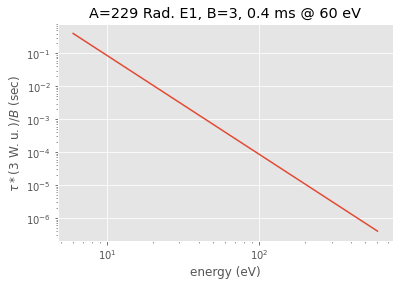

In [16]:
npts = 100
mid = np.log10(60.0)
ran = 1
omegas = np.logspace(mid-ran,mid+ran,npts)
A = 229
E1gammarads = gammaradE(A, 1, omegas, BM1Th229)
E1taus = hbar/E1gammarads*(0.022/3.0)

plt.plot(omegas,E1taus)
plt.xscale("log")
plt.yscale("log")
plt.title("A=229 Rad. E1, B=3, 0.4 ms @ 60 eV")
plt.xlabel('energy (eV)')
plt.ylabel('$\\tau*(3\ \mathrm{W.u.})/B$ (sec)')

print(1000*hbar*(0.022/3.0)/gammaradE(A, 1, 60.0, BM1Th229), " msec for Pa-229 E1 @ 60 eV B = 3 Wu")

Ionization energies of Pa

https://physics.nist.gov/cgi-bin/ASD/ie.pl?spectra=Pa&submit=Retrieve+Data&units=1&format=0&order=0&at_num_out=on&sp_name_out=on&ion_charge_out=on&el_name_out=on&seq_out=on&shells_out=on&level_out=on&ion_conf_out=on&e_out=0&unc_out=on&biblio=on

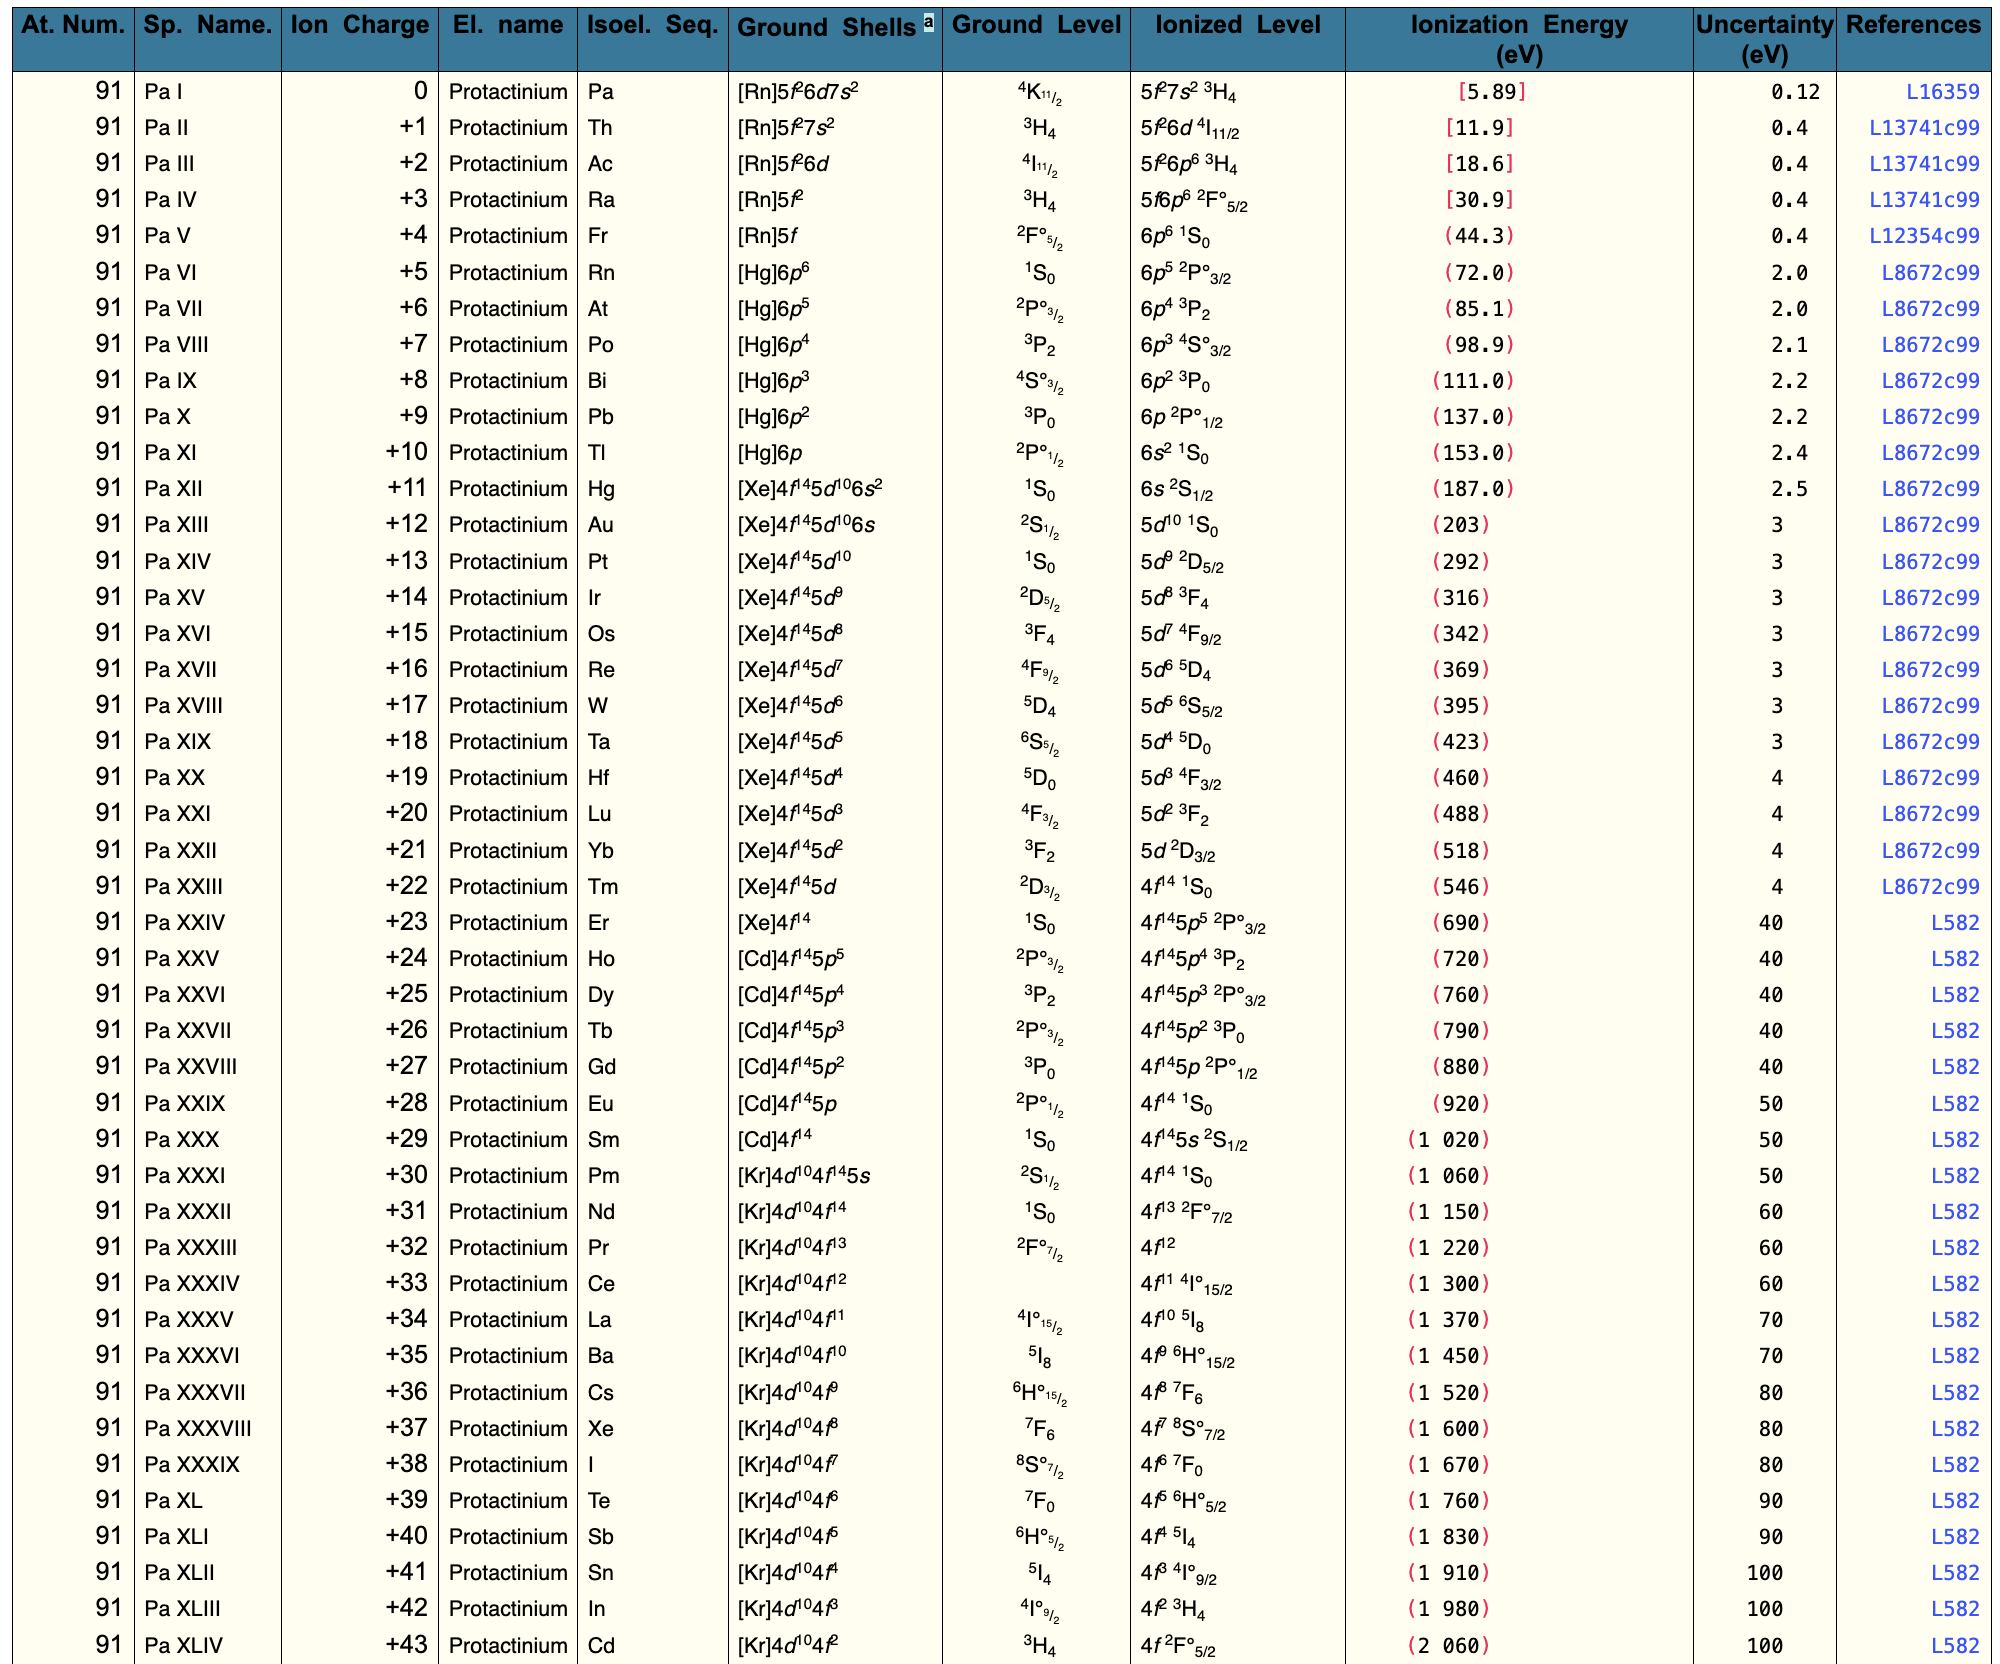

1.2066837699024224  msec for Pa-229 E1 @ 60 eV B = 1 Wu


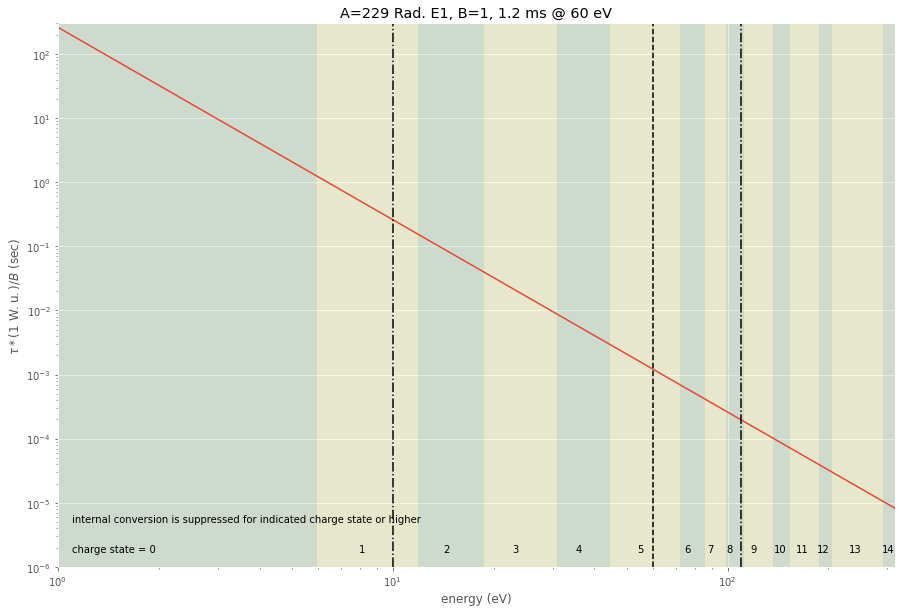

In [17]:
# units are eV - first one is just a placeholder for plotting purposes - should be 0.0
energy_ion = np.array([0.1, 5.89 , 11.9 , 18.6 , 30.9, 44.3, 72.0 , 85.1 , 98.9 , 111.0 , 137.0 , 153.0 , 187.0 , 203 , 292 , 316 , 342 , 369 , 395 , 423 , 460 , 488 , 518 , 546 , 690 , 720 , 760 , 790 , 880 , 920 , 1020 , 1060 , 1150 , 1220 , 1300 , 1370 , 1450 , 1520 , 1600 , 1670 , 1760 , 1830 , 1910 , 1980 , 2060])

npts = 100
mid = np.log10(60.0)
ran = 2
omegas = np.logspace(mid-ran,mid+ran,npts)
A = 229
Bwuinput = 1
E1gammarads = gammaradE(A, 1, omegas, Bwuinput)
E1taus = hbar/E1gammarads

plt.figure(figsize=(15,10))
plt.plot(omegas,E1taus)
plt.xscale("log")
plt.yscale("log")
plt.title("A=229 Rad. E1, B=1, 1.2 ms @ 60 eV")
plt.xlabel('energy (eV)')
plt.ylabel('$\\tau*(1\ \mathrm{W.u.})/B$ (sec)')

plt.annotate("internal conversion is suppressed for indicated charge state or higher",(1.1,5E-6))
ypos = 1.7E-6
plt.annotate("charge state = 0",(1.1,ypos))


count = 0
for count in np.arange(15):
    if (count % 2 == 0):
        color_text = 'green'
    else:
        color_text = 'yellow'
    plt.axvspan(energy_ion[count], energy_ion[count+1], color=color_text, alpha=0.1) 
    plt.annotate(count,(np.sqrt(0.9*energy_ion[count]*energy_ion[count+1]),ypos))

plt.axvline(60, c = 'black' , ls = '--') 
plt.axvline(10, c = 'black' , ls = '-.') 
plt.axvline(110, c = 'black' , ls = '-.') 

plt.xlim(1.0,316.0)
plt.ylim(1E-6,300.0)

plt.savefig("A229-E1-rad.jpg")


print(1000*hbar/gammaradE(A, 1, 60.0, Bwuinput), " msec for Pa-229 E1 @ 60 eV B = 1 Wu")

According to Chapter 10 of Hamilton (1975), the ICC scales as:

$$\alpha_{EL} = \kappa_{EL} Z^3 \alpha^4  \frac{L}{L+1} \left ( \frac{2 m_e c^2}{\omega} \right )^{L +5/2}$$

$$\alpha_{ML} = \kappa_{ML} Z^3 \alpha^4  \left ( \frac{2 m_e c^2}{\omega} \right )^{L +3/2}$$

We'll assume that $\kappa_{M1}$ for Th-229 is a good estimate for $\kappa_{E1}$ for Pa-229.

kappaML =  0.023011924565909444
alpha_E1 =  [1.58582122e+17 1.14509122e+17 8.26848498e+16 5.97051509e+16
 4.31119492e+16 3.11303152e+16 2.24786060e+16 1.62313721e+16
 1.17203638e+16 8.46305088e+15 6.11100741e+15 4.41264174e+15
 3.18628433e+15 2.30075506e+15 1.66133129e+15 1.19961560e+15
 8.66219511e+14 6.25480566e+14 4.51647571e+14 3.26126085e+14
 2.35489418e+14 1.70042411e+14 1.22784378e+14 8.86602541e+13
 6.40198763e+13 4.62275300e+13 3.33800165e+13 2.41030725e+13
 1.74043683e+13 1.25673620e+13 9.07465205e+12 6.55263294e+12
 4.73153110e+12 3.41654824e+12 2.46702424e+12 1.78139109e+12
 1.28630848e+12 9.28818789e+11 6.70682309e+11 4.84286886e+11
 3.49694312e+11 2.52507584e+11 1.82330904e+11 1.31657664e+11
 9.50674844e+10 6.86464149e+10 4.95682652e+10 3.57922976e+10
 2.58449345e+10 1.86621336e+10 1.34755703e+10 9.73045195e+09
 7.02617352e+09 5.07346571e+09 3.66345270e+09 2.64530923e+09
 1.91012727e+09 1.37926642e+09 9.95941943e+08 7.19150656e+08
 5.19284954e+08 3.74965748e+08 2.70755606

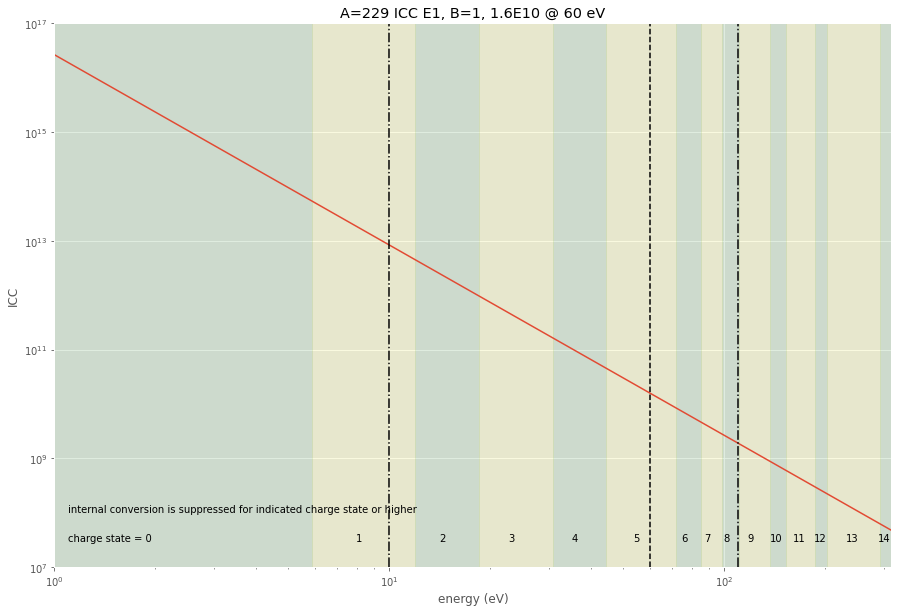

In [18]:
me = 510999.0
omegaTh = 8.36

alphaML = (1740.0)/(7E-6)

kappaML = alphaML/(90**3)/(alpha**4)/((2.0*me/omegaTh)**(1.0+3.0/2.0))

print("kappaML = ",kappaML)

alphaEL = kappaML*(91**3)*(alpha**4)*(1.0/2.0)*((2.0*me/omegas)**(1.0+5.0/2.0))

print("alpha_E1 = " , alphaEL)
print("E1taus (rad) = " , E1taus)

print(1E15*hbar/gammaradE(A, 1, 60.0, Bwuinput)/(kappaML*(91**3)*(alpha**4)*(1.0/2.0)*(2.0*me/60.0)**(1.0+5.0/2.0)), " fs for Pa-229 IC E1 @ 60 eV B = 1 Wu")

print("ICC @ 60 eV = ", (kappaML*(91**3)*(alpha**4)*(1.0/2.0)*(2.0*me/60.0)**(1.0+5.0/2.0)), " for Pa-229 E1 B = 1 Wu")

plt.figure(figsize=(15,10))
plt.plot(omegas,alphaEL)
plt.xscale("log")
plt.yscale("log")
plt.title("A=229 ICC E1, B=1, 1.6E10 @ 60 eV")
plt.xlabel('energy (eV)')
plt.ylabel('ICC')

plt.annotate("internal conversion is suppressed for indicated charge state or higher",(1.1,1E8))
ypos = 3E7
plt.annotate("charge state = 0",(1.1,ypos))


count = 0
for count in np.arange(15):
    if (count % 2 == 0):
        color_text = 'green'
    else:
        color_text = 'yellow'
    plt.axvspan(energy_ion[count], energy_ion[count+1], color=color_text, alpha=0.1) 
    plt.annotate(count,(np.sqrt(0.9*energy_ion[count]*energy_ion[count+1]),ypos))

plt.axvline(60, c = 'black' , ls = '--') 
plt.axvline(10, c = 'black' , ls = '-.') 
plt.axvline(110, c = 'black' , ls = '-.') 

plt.xlim(1.0,316.0)
plt.ylim(1E7,1E17)

plt.savefig("A229-E1-ICC.jpg")

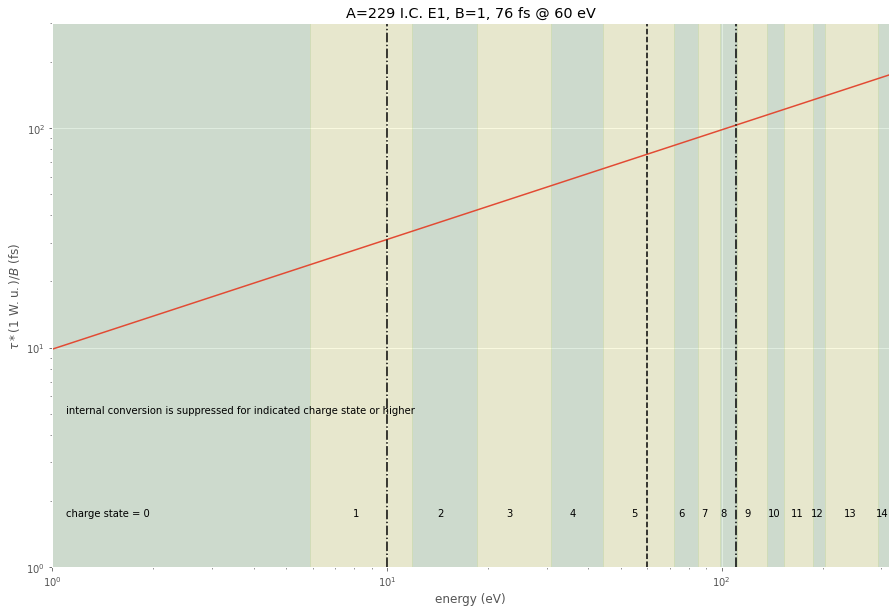

In [19]:
plt.figure(figsize=(15,10))
plt.plot(omegas,1E15*E1taus/alphaEL)
plt.xscale("log")
plt.yscale("log")
plt.title("A=229 I.C. E1, B=1, 76 fs @ 60 eV")
plt.xlabel('energy (eV)')
plt.ylabel('$\\tau*(1\ \mathrm{W.u.})/B$ (fs)')

plt.annotate("internal conversion is suppressed for indicated charge state or higher",(1.1,5))
ypos = 1.7
plt.annotate("charge state = 0",(1.1,ypos))


count = 0
for count in np.arange(15):
    if (count % 2 == 0):
        color_text = 'green'
    else:
        color_text = 'yellow'
    plt.axvspan(energy_ion[count], energy_ion[count+1], color=color_text, alpha=0.1) 
    plt.annotate(count,(np.sqrt(0.9*energy_ion[count]*energy_ion[count+1]),ypos))

plt.axvline(60, c = 'black' , ls = '--') 
plt.axvline(10, c = 'black' , ls = '-.') 
plt.axvline(110, c = 'black' , ls = '-.') 

plt.xlim(1.0,316.0)
plt.ylim(1,300.0)

plt.savefig("A229-E1-IC.jpg")

Assuming now that B(E1) is more like 3E-4 in W.u.

4.022279233008074  sec for Pa-229 E1 @ 60 eV B = 3E-4 Wu


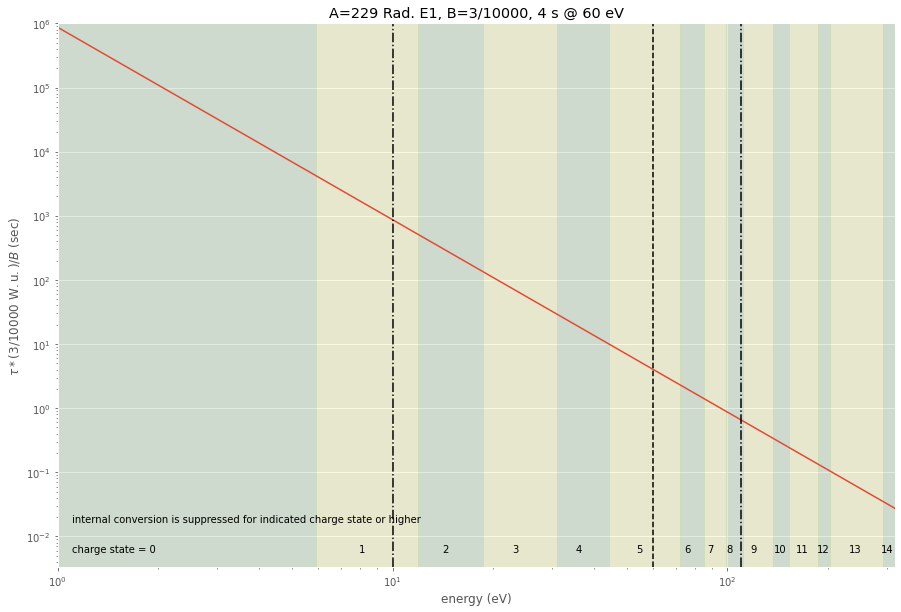

In [66]:
# units are eV - first one is just a placeholder for plotting purposes - should be 0.0
energy_ion = np.array([0.1, 5.89 , 11.9 , 18.6 , 30.9, 44.3, 72.0 , 85.1 , 98.9 , 111.0 , 137.0 , 153.0 , 187.0 , 203 , 292 , 316 , 342 , 369 , 395 , 423 , 460 , 488 , 518 , 546 , 690 , 720 , 760 , 790 , 880 , 920 , 1020 , 1060 , 1150 , 1220 , 1300 , 1370 , 1450 , 1520 , 1600 , 1670 , 1760 , 1830 , 1910 , 1980 , 2060])

npts = 100
mid = np.log10(60.0)
ran = 2
omegas = np.logspace(mid-ran,mid+ran,npts)
A = 229
Bwuinput = 3E-4
E1gammarads = gammaradE(A, 1, omegas, Bwuinput)
E1taus = hbar/E1gammarads

plt.figure(figsize=(15,10))
plt.plot(omegas,E1taus)
plt.xscale("log")
plt.yscale("log")
plt.title("A=229 Rad. E1, B=3/10000, 4 s @ 60 eV")
plt.xlabel('energy (eV)')
plt.ylabel('$\\tau*(3/10000\ \mathrm{W.u.})/B$ (sec)')

plt.annotate("internal conversion is suppressed for indicated charge state or higher",(1.1,5E-6/Bwuinput))
ypos = 1.7E-6/Bwuinput
plt.annotate("charge state = 0",(1.1,ypos))


count = 0
for count in np.arange(15):
    if (count % 2 == 0):
        color_text = 'green'
    else:
        color_text = 'yellow'
    plt.axvspan(energy_ion[count], energy_ion[count+1], color=color_text, alpha=0.1) 
    plt.annotate(count,(np.sqrt(0.9*energy_ion[count]*energy_ion[count+1]),ypos))

plt.axvline(60, c = 'black' , ls = '--') 
plt.axvline(10, c = 'black' , ls = '-.') 
plt.axvline(110, c = 'black' , ls = '-.') 

plt.xlim(1.0,316.0)
plt.ylim(1E-6/Bwuinput,300.0/Bwuinput)

plt.savefig("A229-E1-rad2.jpg")


print(hbar/gammaradE(A, 1, 60.0, Bwuinput), " sec for Pa-229 E1 @ 60 eV B = 3E-4 Wu")

kappaML =  0.023011924565909444
alpha_E1 =  [1.58582122e+17 1.14509122e+17 8.26848498e+16 5.97051509e+16
 4.31119492e+16 3.11303152e+16 2.24786060e+16 1.62313721e+16
 1.17203638e+16 8.46305088e+15 6.11100741e+15 4.41264174e+15
 3.18628433e+15 2.30075506e+15 1.66133129e+15 1.19961560e+15
 8.66219511e+14 6.25480566e+14 4.51647571e+14 3.26126085e+14
 2.35489418e+14 1.70042411e+14 1.22784378e+14 8.86602541e+13
 6.40198763e+13 4.62275300e+13 3.33800165e+13 2.41030725e+13
 1.74043683e+13 1.25673620e+13 9.07465205e+12 6.55263294e+12
 4.73153110e+12 3.41654824e+12 2.46702424e+12 1.78139109e+12
 1.28630848e+12 9.28818789e+11 6.70682309e+11 4.84286886e+11
 3.49694312e+11 2.52507584e+11 1.82330904e+11 1.31657664e+11
 9.50674844e+10 6.86464149e+10 4.95682652e+10 3.57922976e+10
 2.58449345e+10 1.86621336e+10 1.34755703e+10 9.73045195e+09
 7.02617352e+09 5.07346571e+09 3.66345270e+09 2.64530923e+09
 1.91012727e+09 1.37926642e+09 9.95941943e+08 7.19150656e+08
 5.19284954e+08 3.74965748e+08 2.70755606

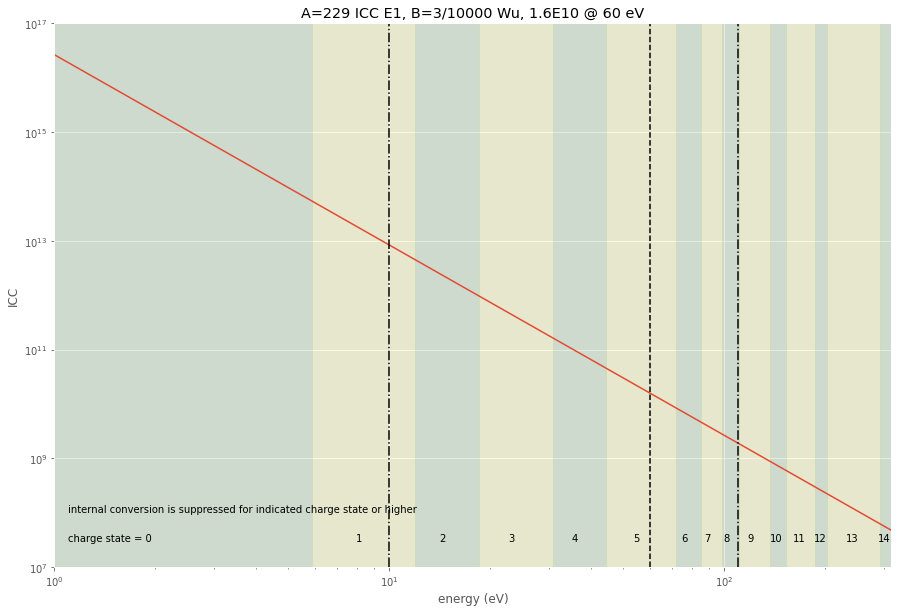

In [67]:
me = 510999.0
omegaTh = 8.36

alphaML = (1740.0)/(7E-6)

kappaML = alphaML/(90**3)/(alpha**4)/((2.0*me/omegaTh)**(1.0+3.0/2.0))

print("kappaML = ",kappaML)

alphaEL = kappaML*(91**3)*(alpha**4)*(1.0/2.0)*((2.0*me/omegas)**(1.0+5.0/2.0))

print("alpha_E1 = " , alphaEL)
print("E1taus (rad) = " , E1taus)

print(1E9*hbar/gammaradE(A, 1, 60.0, Bwuinput)/(kappaML*(91**3)*(alpha**4)*(1.0/2.0)*(2.0*me/60.0)**(1.0+5.0/2.0)), " ns for Pa-229 IC E1 @ 60 eV B = 3E-4 Wu")

print("ICC @ 60 eV = ", (kappaML*(91**3)*(alpha**4)*(1.0/2.0)*(2.0*me/60.0)**(1.0+5.0/2.0)), " for Pa-229 E1 B = 3E-4 Wu")

plt.figure(figsize=(15,10))
plt.plot(omegas,alphaEL)
plt.xscale("log")
plt.yscale("log")
plt.title("A=229 ICC E1, B=3/10000 Wu, 1.6E10 @ 60 eV")
plt.xlabel('energy (eV)')
plt.ylabel('ICC')

plt.annotate("internal conversion is suppressed for indicated charge state or higher",(1.1,1E8))
ypos = 3E7
plt.annotate("charge state = 0",(1.1,ypos))


count = 0
for count in np.arange(15):
    if (count % 2 == 0):
        color_text = 'green'
    else:
        color_text = 'yellow'
    plt.axvspan(energy_ion[count], energy_ion[count+1], color=color_text, alpha=0.1) 
    plt.annotate(count,(np.sqrt(0.9*energy_ion[count]*energy_ion[count+1]),ypos))

plt.axvline(60, c = 'black' , ls = '--') 
plt.axvline(10, c = 'black' , ls = '-.') 
plt.axvline(110, c = 'black' , ls = '-.') 

plt.xlim(1.0,316.0)
plt.ylim(1E7,1E17)

plt.savefig("A229-E1-ICC2.jpg")

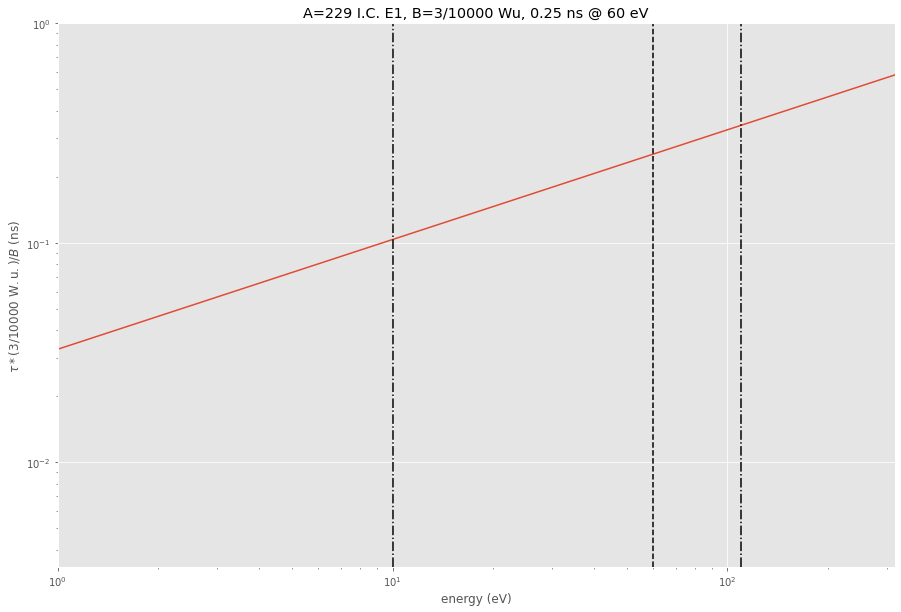

In [68]:
plt.figure(figsize=(15,10))
plt.plot(omegas,1E9*E1taus/alphaEL)
plt.xscale("log")
plt.yscale("log")
plt.title("A=229 I.C. E1, B=3/10000 Wu, 0.25 ns @ 60 eV")
plt.xlabel('energy (eV)')
plt.ylabel('$\\tau*(3/10000\ \mathrm{W.u.})/B$ (ns)')

#plt.annotate("internal conversion is suppressed for indicated charge state or higher",(1.1,5/Bwuinput/1E6))
#ypos = 1.7/Bwuinput/1E6
#plt.annotate("charge state = 0",(1.1,ypos))

#
#count = 0
#for count in np.arange(15):
#    if (count % 2 == 0):
#        color_text = 'green'
#    else:
#        color_text = 'yellow'
#    plt.axvspan(energy_ion[count], energy_ion[count+1], color=color_text, alpha=0.1) 
#    plt.annotate(count,(np.sqrt(0.9*energy_ion[count]*energy_ion[count+1]),ypos))

plt.axvline(60, c = 'black' , ls = '--') 
plt.axvline(10, c = 'black' , ls = '-.') 
plt.axvline(110, c = 'black' , ls = '-.') 

plt.xlim(1.0,316.0)
plt.ylim(1/Bwuinput/1E6,300.0/Bwuinput/1E6)

plt.savefig("A229-E1-IC2.jpg")

1


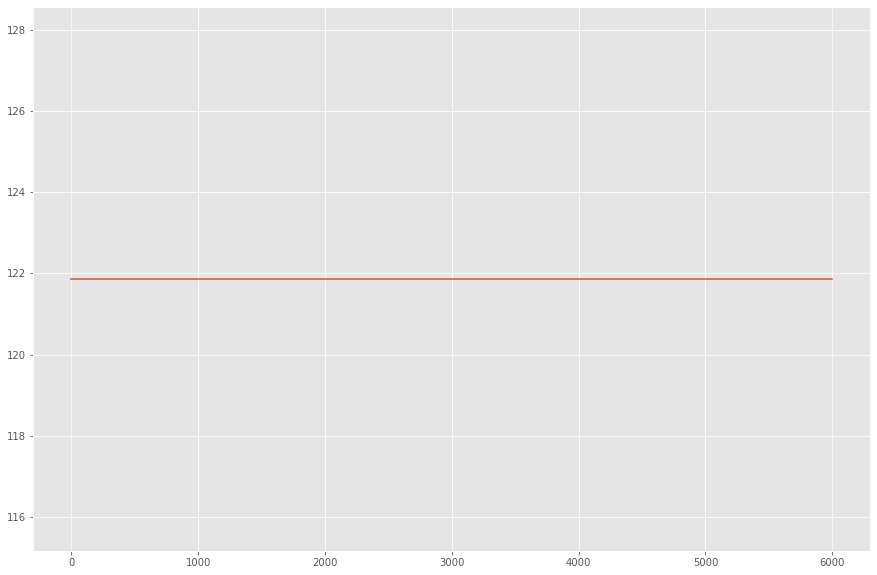

2


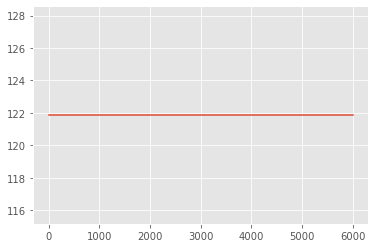

3


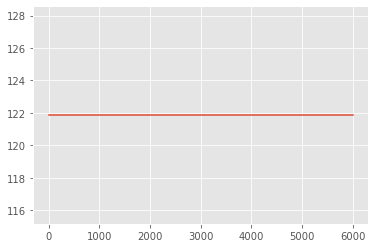

4


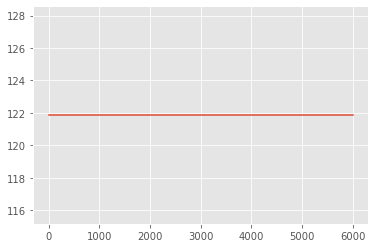

5


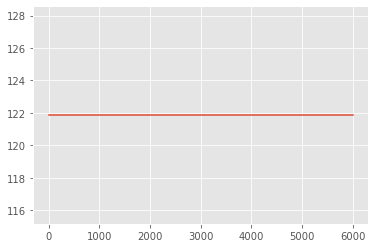

No handles with labels found to put in legend.


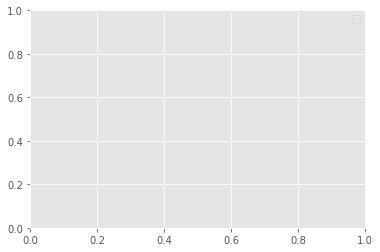

In [66]:
plt.figure(figsize=(15,10))
A = 229
Ls = np.array([1,2,3,4,5])
B = 3E-4
for L in Ls:
    print(L)
    Erates = gammaradE(A, L, omegas, B)
    Mrates = gammaradM(A, L, omegas, B)
    plt.plot(omegas,Erates/Mrates,label=f"{L}")
    plt.show()
    
plt.legend()

In [ ]:
plt.

ValueError: x and y must have same first dimension, but have shapes (1,) and (101,)

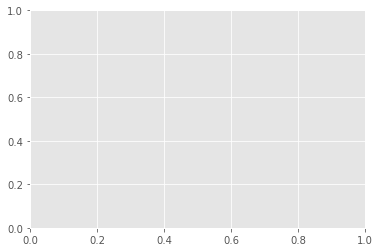

In [22]:
omegas = np.linspace(1,101,101)
rats = gammaradM(229, 1, omegas, 1)/gammaradM(229, 1, omegas, 1)
plt.plot(omega,rats)

In [25]:
omegas = np.linspace(1,101,101)
print(gammaradE(229, 1, omegas, 1)/gammaradM(229, 1, omegas, 1))

[121.86270165 121.86270165 121.86270165 121.86270165 121.86270165
 121.86270165 121.86270165 121.86270165 121.86270165 121.86270165
 121.86270165 121.86270165 121.86270165 121.86270165 121.86270165
 121.86270165 121.86270165 121.86270165 121.86270165 121.86270165
 121.86270165 121.86270165 121.86270165 121.86270165 121.86270165
 121.86270165 121.86270165 121.86270165 121.86270165 121.86270165
 121.86270165 121.86270165 121.86270165 121.86270165 121.86270165
 121.86270165 121.86270165 121.86270165 121.86270165 121.86270165
 121.86270165 121.86270165 121.86270165 121.86270165 121.86270165
 121.86270165 121.86270165 121.86270165 121.86270165 121.86270165
 121.86270165 121.86270165 121.86270165 121.86270165 121.86270165
 121.86270165 121.86270165 121.86270165 121.86270165 121.86270165
 121.86270165 121.86270165 121.86270165 121.86270165 121.86270165
 121.86270165 121.86270165 121.86270165 121.86270165 121.86270165
 121.86270165 121.86270165 121.86270165 121.86270165 121.86270165
 121.86270